# Information

## Team

Tutor Group 1 Team E

## Members

Maximilian von Quast

Tobias Radspieler

Sourabh Saini

Raghvendra Singh

Unfortunately, our fifth team member Abidur Rahman Raktim ended up having to drop the project and could not contribute to the project at all.

## Topic

Topic 3: Healthcare Analytics

Our data consists of fictional hospital data featuring various information about individual hospital stays of patients across multiple hospitals.

# Package Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")   # Future warnings for accessing and modifying sliced data is irrelevant in our case

# Data Import

In [2]:
hadata = pd.read_csv("Topic3_healthcare_analytics_dataset.csv")
df = hadata
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,455495.00000,455495.000000,455495.000000,455495.000000,455347.000000,455495.000000,448806.000000,455495.000000,455495.000000
mean,227748.00000,18.326335,4.767798,3.196140,2.628420,65786.793563,7.249495,3.284229,4877.434022
std,131490.22477,8.634036,3.102450,1.166994,0.871997,37968.830850,4.758941,1.768044,1084.982089
min,1.00000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,113874.50000,11.000000,2.000000,2.000000,2.000000,32874.000000,4.000000,2.000000,4184.000000
50%,227748.00000,19.000000,5.000000,3.000000,3.000000,65735.000000,8.000000,3.000000,4738.000000
75%,341621.50000,26.000000,7.000000,4.000000,3.000000,98576.500000,8.000000,4.000000,5405.000000
max,455495.00000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11920.000000


For testing purposes we included a test sample spanning only the first 1000 entries. This made plotting and analysis testing much faster. In the final notebook this testing sub sample is not used anymore.

In [3]:
df_test = hadata[:1000]
df_test.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,1000.000000,1000.000000,1000.00000,1000.000000,999.000000,1000.000000,992.000000,1000.00000,1000.000000
mean,500.500000,19.274000,4.94200,3.228000,2.473473,71961.999000,7.336694,3.21000,4800.338000
std,288.819436,8.604706,3.21885,1.207259,0.842893,37392.818016,4.593852,1.51862,1050.736485
min,1.000000,1.000000,1.00000,1.000000,1.000000,349.000000,1.000000,1.00000,2118.000000
25%,250.750000,12.000000,2.00000,2.000000,2.000000,40546.500000,5.000000,2.00000,4097.000000
50%,500.500000,21.000000,5.00000,3.000000,2.000000,74756.000000,8.000000,3.00000,4710.000000
75%,750.250000,26.000000,7.00000,4.000000,3.000000,106975.000000,8.000000,4.00000,5310.750000
max,1000.000000,32.000000,13.00000,9.000000,4.000000,130669.000000,28.000000,15.00000,9423.000000


To get a better understanding of the data set we are working with we implemented a custom function to create data statistics for a first look.

In [4]:
def createDataStatistics(df: pd.DataFrame) -> pd.DataFrame:
    """creates data statistics

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resulting statistics DataFrame
    """
    df_statistics = pd.DataFrame(index=df.columns, columns=["Uniques", "Cases", "Min", "Max", "Mean", "Median", "Split"])
    for column in df:
        df_statistics.at[column, "Uniques"] = df[column].value_counts().size
        list = df[column].value_counts(normalize=True).keys().tolist()
        list.sort()
        df_statistics.at[column, "Cases"] = list
        if pd.api.types.is_numeric_dtype(df[column]):
            df_statistics.at[column, "Min"] = df[column].min()
            df_statistics.at[column, "Max"] = df[column].max()
            df_statistics.at[column, "Mean"] = df[column].mean()
            df_statistics.at[column, "Median"] = df[column].median()
        df_statistics.at[column, "Split"] = df[column].value_counts(normalize=True)
    return df_statistics

In [5]:
createDataStatistics(df)

,Uniques,Cases,Min,Max,Mean,Median,Split
case_id,455495,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,455495,227748.0,227748.0,case_id 1 0.000002 303661 0.000002 ...
Hospital_code,32,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,32,18.326335,19.0,Hospital_code 26 0.104333 23 0.083909 19...
Hospital_type_code,7,"[a, b, c, d, e, f, g]",NaN,NaN,NaN,NaN,Hospital_type_code a 0.449467 b 0.217091...
City_Code_Hospital,11,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13]",1,13,4.767798,5.0,City_Code_Hospital 1 0.173565 2 0.1631...
Hospital_region_code,3,"[X, Y, Z]",NaN,NaN,NaN,NaN,Hospital_region_code X 0.418993 Y 0.3835...
Available Extra Rooms in Hospital,18,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,24,3.19614,3.0,Available Extra Rooms in Hospital 2 0.3093...
Department,5,"[TB & Chest disease, anesthesia, gynecology, r...",NaN,NaN,NaN,NaN,Department gynecology 0.783078 anes...
Ward_Type,6,"[P, Q, R, S, T, U]",NaN,NaN,NaN,NaN,Ward_Type R 0.401627 Q 0.333804 S 0.2...
Ward_Facility_Code,6,"[A, B, C, D, E, F]",NaN,NaN,NaN,NaN,Ward_Facility_Code F 0.354493 E 0.173565...
Bed Grade,4,"[1.0, 2.0, 3.0, 4.0]",1.0,4.0,2.62842,3.0,Bed Grade 2.0 0.387509 3.0 0.349057 4.0 ...


# Data Cleaning

## Separating Provided Training and Test Data

The data set excel file provided on Moodle includes both the original training data and the test data from kaggle.com. Those separate data bases are concatenated into a single excel file on Moodle totalling 455495 rows.
The testing data is clearly separable from the rest because all entries from 318439 to the end 455495 all have the Stay column empty. For this project we are only working on the training data which includes the rows with filled in Stay values spanning the rows from 0 to 318438.

In [6]:
df_cropped = hadata[:318438]
df = df_cropped
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276847,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


## Missing Values

Regarding any missing values, we decided to generally drop any rows featuring any missing values as they were not statistically meaningful.

However, there is one exception. The column City_Code_Patient sometimes has empty values and because this value is only descriptively encoding an arbitrary ID for the cities' patients, it can still be used for our analysis and we chose to fill in emtpy cells in this column with a dummy value of -1.

For this purpose we implemented various functions to handle missing values.

In [7]:
def handleMissingEntries(*, df:pd.DataFrame) -> pd.DataFrame:
    """fills missing values in City_Code_Patient with ddmmy value and removes any other rows featuring emtpy values

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    df = fillMissingEntries(df=df, column="City_Code_Patient", method="-1", significant=1)
    for column in df:
        df = removeMissingEntries(df=df, column=column)
    return df

def removeMissingEntries(*,df: pd.DataFrame, column: str) -> pd.DataFrame:
    """removes rows with empty values in given column in DataFrame

    Args:
        df (pd.DataFrame): working DataFrame
        column (str): column to operate on

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    df = df.dropna(subset=column)
    return df

def fillMissingEntries(*,df: pd.DataFrame, column: str, method: str, significant: float) -> pd.DataFrame:
    """fills missing entries based on given column, method, and significant

    Args:
        df (pd.DataFrame): working DataFrame
        column (str): working column string
        method (str): method choice: 'mean', 'median', or '-1'
        significant (float): the maxium percentage of missing values to still fill in the empty cells, no action if missing value percentage is higher than significant

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    missingMatrix = df.isnull()
    percentageMatrix = missingMatrix.mean()
    if percentageMatrix[column] <= significant:
        match method:
            case "mean":
                df.fillna({column: df[column].mean()}, inplace=True)
            case "median":
                df.fillna({column: df[column].median()}, inplace=True)
            case "-1":
                df.fillna({column: -1}, inplace=True)
    return df

## Categorical Encoding

The provided data already includes many encoded columns like the patient, hospital, and city codes, as well as the bed grade. Unfortunately, the Age and Stay columns only field values as ranges like for example "11-20". To allow deeper analysis on it we need to encode this numerically. This sparked quite some discussion within the team on how to implement this the best. Some possible impelmentations include encoding the ranges as the minimum ("11" in the example) or encoding it as the mean in the given range ("15" in the example). The data is deliberately ambigious giving us only ranges instead of numerical values, so no matter which encoding method is used, we will end up with some uncertainty in the data. Ultimatively we decided on using the mean replacement approach for our analysis.

In [8]:
def encodeData(*, df: pd.DataFrame) -> pd.DataFrame:
    """encodes data, particularly Stay and Age columns

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    df = encodeStay(df)
    df = encodeAge(df)
    return df

def encodeStay(df: pd.DataFrame) -> pd.DataFrame:
    """encodes Stay ranged values as median values

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    df["Stay"] = df["Stay"].replace({'0-10': 5, '11-20': 15, '21-30': 25, '31-40': 35, '41-50': 45, '51-60': 55, '61-70': 65, '71-80': 75, '81-90': 85, '91-100': 95, 'More than 100 Days': 110})
    return df

def encodeAge(df: pd.DataFrame) -> pd.DataFrame:
    """encodes Age ranged values as median values

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resultingDataFrame
    """
    df["Age"] = df["Age"].replace({'0-10': 5, '11-20': 15, '21-30': 25, '31-40': 35, '41-50': 45, '51-60': 55, '61-70': 65, '71-80': 75, '81-90': 85, '91-100': 95})
    return df

def encode(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """performs generic dummy encoding on column

    Args:
        df (pd.DataFrame): working DataFrame
        column (str): column to encode

    Returns:
        pd.DataFrame: resulting DataFrme
    """
    df = pd.get_dummies(df, columns=list().append(column), drop_first=True, dtype=float)
    return df

## Outliers

The provided data has practically no statistical outliers. Therefore, handling outliers is not necessary. Nonetheless, we implemented a simple outlier handling function incase we needed it at some point.

In [9]:
def handleOutliers(*,df: pd.DataFrame, column: str, method: str, action: str, threshhold: float) -> pd.DataFrame:
    """handles outliers based on given column, method, action, and threshhold

    Args:
        df (pd.DataFrame): working DataFrame
        column (str): working column str
        method (str): method to be determine outliers, choices: 'iqr' or 'zscore'
        action (str): action to be performed on outliers, choices: 'remove', 'cap', or 'flag'
        threshhold (float): the threshold value used to determine outliers

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    lower_bound = float()
    upper_bound = float()
    outliers = pd.DataFrame()
    match method:
        case "iqr":
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            iqr = Q3 - Q1
            lower_bound = Q1 - iqr * threshhold
            upper_bound = Q3 + iqr * threshhold
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        case "zscore":
            mean = df[column].mean()
            std = df[column].std()
            lower_bound = mean - std * threshhold
            upper_bound = mean + std * threshhold
            outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    match action:
        case "remove":
            df = df.drop(outliers.index)
        case "cap":
            df[column] = df[column].clip(upper=upper_bound, lower=lower_bound)
        case "flag":
            outl_col_name = column + "Outlier"
            df[outl_col_name] = False
            for index in outliers.index.to_list():
                df.at[index, outl_col_name] = True
    return df

## Preprocessing Pipeline

To streamline the data preprocessing we implemented a pipeline function that passes all contextual parameters along to the previously defined functions.
While many of those parameters ended up being irrelevant for our final analysis, it has still proven to be good practice to have an all-encompassing pipeline function.

In [10]:
def preprocessDataPipeline(*, df: pd.DataFrame, numericalFeatures: list[str], categoricalFeatures: list[str], missingEntriesMethod: str, missingEntriesSignificant: float, outliersMethod: str, outliersAction: str, outliersThreshold: float) -> pd.DataFrame:
    """
    Executes various preprocessing tasks.

    Parameters:
    -----------
    df: pandas.DataFrame
        The DataFrame to work on
    numericalFeatures: list[str]
        The list of numerical features (i. e. columns) to be transformed
    categoricalFeatures: list[str]
        The list of categorical features (i. e. columns) to be transformed
    missingEntriesMethod: str
        The method to be used on cells with missing data
        Options: "mean", "median"
    missingEntriesSignificant: float
        The significant threshold for filling in data
    outliersMethod: str
        The method to be used to identify outliers
        Options: "iqr", "zscore"
    outliersAction: str
        The action to be used on outliers
        Options: "remove", "cap", "flag"
    outliersThreshold: float
        The threshold to be used to calculate outlier boundries
    """

    df = encodeData(df=df)
    df = handleMissingEntries(df=df)
    return df

In [11]:
numericalFeatures = ["Available Extra Rooms in Hospital", "Bed Grade", "Visitors with Patient", "Admission_Deposit", "Stay", "Age"]
categoricalFeatures = ["case_Id", "Hospital_code", "Hospital_type_code", "City_Code_Hospital", "Hospital_region_code", "Department", "Ward_Type", "patientid", "City_Code_Patient", "Type of Admission", "Severity of Illness", "Stay"]
preparedDataFrame = df.copy()
preparedDataFrame = preprocessDataPipeline(df=preparedDataFrame, numericalFeatures=numericalFeatures, categoricalFeatures=categoricalFeatures, missingEntriesMethod="mean", missingEntriesSignificant=0.2, outliersMethod="zscore", outliersAction="cap", outliersThreshold=3)

We are taking a quick look comparing the original data to the cleaned data.

In [12]:
print("Original Data:")
df.describe()

Original Data:


,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276847,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [13]:
print("Prepared Data:")
preparedDataFrame.describe()

Prepared Data:


,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Age,Admission_Deposit,Stay
count,318325.000000,318325.000000,318325.000000,318325.000000,318325.000000,318325.000000,318325.000000,318325.000000,318325.00000,318325.000000,318325.000000
mean,159221.359369,18.323163,4.771297,3.197509,2.625807,65748.181962,7.134956,3.284153,46.27841,4880.857705,32.089186
std,91932.122176,8.632207,3.102999,1.168208,0.873146,37980.537188,4.811708,1.764190,18.89657,1086.848051,21.866389
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,-1.000000,0.000000,5.00000,1800.000000,5.000000
25%,79601.000000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,35.00000,4186.000000,15.000000
50%,159222.000000,19.000000,5.000000,3.000000,3.000000,65726.000000,8.000000,3.000000,45.00000,4741.000000,25.000000
75%,238857.000000,26.000000,7.000000,4.000000,3.000000,98472.000000,8.000000,4.000000,55.00000,5409.000000,35.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,95.00000,11008.000000,110.000000


# Problem Statement

The are many variables to evaluate in this healthcare data. The most meaningful analysis on the data set constitutes predicting variables with concrete practical use cases. Healthcare institions, like hospitals in this case, can optimize their caregiving infrastructure like room assignments and staff shift assignments, as well as minimize overhead costs like wasted food and cleaning costs if they have reliable predictions on the stay time of a patient.

Therefore, we are trying to predict how long a patient will stay during a hospital visit based on the giving features of the data set. After some initial assessment we came to the conclusion that the best predictors for the stay time should be the age of the patient and how many visitors are with the patient.

We are analysis the data to find answers for the research question: Can we predict a patient's Stay time from the Number of Visitors and the patient's Age?

# Data Analysis

## Value Scaling

To perform numerical analysis on the data we scale all native and encoded numerical values using a standard scalar.

In [14]:
def scaleData(*, df: pd.DataFrame) -> pd.DataFrame:
    """scales numeric data

    Args:
        df (pd.DataFrame): working DataFrame

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    scaled_df = df.copy()
    for column in scaled_df.select_dtypes(include=np.number):
        scaled_df = scaleColumn(df=scaled_df, column=column)
    return scaled_df

def scaleColumn(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """scales column using a Standard Scaler

    Args:
        df (pd.DataFrame): working DataFrame
        column (str): column to scale

    Returns:
        pd.DataFrame: resulting DataFrame
    """
    scaled_df = df
    scaler = StandardScaler()
    scaled_df[column] = scaler.fit_transform(pd.DataFrame(scaled_df[column]))
    return scaled_df

We can take a look comparing the original data to the scaled data.

In [15]:
print("Scaled Data:")
scaledDataFrame = scaleData(df=preparedDataFrame)
scaledDataFrame.describe()

Scaled Data:


,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Age,Admission_Deposit,Stay
count,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05,3.183250e+05
mean,3.999977e-17,-2.285701e-17,-1.122761e-16,-2.714270e-17,-2.042845e-16,-1.426331e-17,-1.285707e-17,-3.392837e-17,1.142850e-17,-1.107136e-16,1.392849e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.731937e+00,-2.006809e+00,-1.215373e+00,-2.737109e+00,-1.862014e+00,-1.731078e+00,-1.690662e+00,-1.861568e+00,-2.184443e+00,-2.834676e+00,-1.238852e+00
25%,-8.660790e-01,-8.483549e-01,-8.931040e-01,-1.025083e+00,-7.167279e-01,-8.662656e-01,-6.515278e-01,-7.279008e-01,-5.968505e-01,-6.393339e-01,-7.815288e-01
50%,6.968537e-06,7.840841e-02,7.370409e-02,-1.690701e-01,4.285580e-01,-5.840359e-04,1.797792e-01,-1.610674e-01,-6.765315e-02,-1.286821e-01,-3.242052e-01
75%,8.662453e-01,8.893263e-01,7.182428e-01,6.869429e-01,4.285580e-01,8.615958e-01,1.797792e-01,4.057660e-01,4.615442e-01,4.859402e-01,1.331184e-01
max,1.731896e+00,1.584399e+00,2.651859e+00,1.780720e+01,1.573844e+00,1.734465e+00,6.414582e+00,1.627710e+01,2.578334e+00,5.637542e+00,3.563045e+00


In [16]:
createDataStatistics(preparedDataFrame)

,Uniques,Cases,Min,Max,Mean,Median,Split
case_id,318325,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,318438,159221.359369,159222.0,case_id 1 0.000003 212286 0.000003 ...
Hospital_code,32,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1,32,18.323163,19.0,Hospital_code 26 0.103906 23 0.083456 19...
Hospital_type_code,7,"[a, b, c, d, e, f, g]",NaN,NaN,NaN,NaN,Hospital_type_code a 0.450207 b 0.216590...
City_Code_Hospital,11,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13]",1,13,4.771297,5.0,City_Code_Hospital 1 0.173882 2 0.1627...
Hospital_region_code,3,"[X, Y, Z]",NaN,NaN,NaN,NaN,Hospital_region_code X 0.418516 Y 0.3845...
Available Extra Rooms in Hospital,18,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0,24,3.197509,3.0,Available Extra Rooms in Hospital 2 0.3087...
Department,5,"[TB & Chest disease, anesthesia, gynecology, r...",NaN,NaN,NaN,NaN,Department gynecology 0.783435 anes...
Ward_Type,6,"[P, Q, R, S, T, U]",NaN,NaN,NaN,NaN,Ward_Type R 0.401712 Q 0.333386 S 0.2...
Ward_Facility_Code,6,"[A, B, C, D, E, F]",NaN,NaN,NaN,NaN,Ward_Facility_Code F 0.353855 E 0.173882...
Bed Grade,4,"[1.0, 2.0, 3.0, 4.0]",1.0,4.0,2.625807,3.0,Bed Grade 2.0 0.388505 3.0 0.347390 4.0 ...


In [17]:
createDataStatistics(scaledDataFrame)

,Uniques,Cases,Min,Max,Mean,Median,Split
case_id,318325,"[-1.7319366255295339, -1.7319257479217178, -1....",-1.731937,1.731896,0.0,0.000007,case_id -1.731937 0.000003 0.577216 0.0...
Hospital_code,32,"[-2.00680904749805, -1.8909636330510615, -1.77...",-2.006809,1.584399,-0.0,0.078408,Hospital_code 0.889326 0.103906 0.541790 ...
Hospital_type_code,7,"[a, b, c, d, e, f, g]",NaN,NaN,NaN,NaN,Hospital_type_code a 0.450207 b 0.216590...
City_Code_Hospital,11,"[-1.2153733200408274, -0.8931039684034267, -0....",-1.215373,2.651859,-0.0,0.073704,City_Code_Hospital -1.215373 0.173882 -0.89...
Hospital_region_code,3,"[X, Y, Z]",NaN,NaN,NaN,NaN,Hospital_region_code X 0.418516 Y 0.3845...
Available Extra Rooms in Hospital,18,"[-2.7371091041831868, -1.881096112457404, -1.0...",-2.737109,17.807203,-0.0,-0.16907,Available Extra Rooms in Hospital -1.025083 ...
Department,5,"[TB & Chest disease, anesthesia, gynecology, r...",NaN,NaN,NaN,NaN,Department gynecology 0.783435 anes...
Ward_Type,6,"[P, Q, R, S, T, U]",NaN,NaN,NaN,NaN,Ward_Type R 0.401712 Q 0.333386 S 0.2...
Ward_Facility_Code,6,"[A, B, C, D, E, F]",NaN,NaN,NaN,NaN,Ward_Facility_Code F 0.353855 E 0.173882...
Bed Grade,4,"[-1.8620137707161968, -0.7167278797846979, 0.4...",-1.862014,1.573844,-0.0,0.428558,Bed Grade -0.716728 0.388505 0.428558 0...


## Linear Regression

The cornerstone of our analysis is performing a fitting regression analysis. Because our data is scaling mostly linearly instead of polynomial or logarithmic, the best regression model for our research is a simple linear regression. We split the data into training and test data to populate and fit the linear regression model.

Finally, we evaluate the results using the "mean squared error" method and the StatsModel method.

In [18]:
def prepareAnalysisData(df: pd.DataFrame, targetCol: str) -> list:
    """prepares the data frame for regression analysis by cropping the target column and splitting the data into training and testing

    Args:
        df (pd.DataFrame): working DataFrame
        targetCol (str): target column

    Returns:
        list: list of resulting train and testing data subset
    """
    X = df.drop(columns=targetCol)
    y = df[targetCol]
    return train_test_split(X, y, test_size=0.2, random_state=1)

def evaluatePrediction(X_train, y_train, y_test, y_pred, method: str):
    """evalutes prediction results based on given method

    Args:
        X_train (_type_): X of train data
        y_train (_type_): y of train data
        y_test (_type_): y of test data
        y_pred (_type_): y of prediction
        method (str): type of evaluation method, choices: 'mean squared error', or 'StatsModel'
    """
    match method:
        case "mean squared error":
            mse = mean_squared_error(y_test, y_pred)
            print("Mean squared error:")
            print(mse)
        case "StatsModel":
            X_train = sm.add_constant(X_train)
            model = sm.OLS(y_train, X_train)
            results = model.fit()
            print("StatsModel Analysis:")
            print(results.summary())

def linearRegression(X_train, X_test, y_train, y_test, predictorsCol: list[str], evalMethods: list[str]):
    """performs linear regression on given data and evaluates the results based on given evaluation method

    Args:
        X_train (_type_): X of train data
        X_test (_type_): X of test data
        y_train (_type_): y of train data
        y_test (_type_): y of test data
        predictorsCol (list[str]): columns to be used as predictors
        evalMethods (list[str]): method to be used to evaluate the regression
    """
    X_train = X_train[predictorsCol]
    X_test = X_test[predictorsCol]
    regressor = LinearRegression()
    regressor.fit(X_train, y_train)
    y_pred = regressor.predict(X_test)

    print("===========================================================================================================================")
    print("===========================================================================================================================")
    print("Analysis:")
    for eval in evalMethods:
        print("Evaluation of " + str(predictorsCol) + "according to " + eval)
        evaluatePrediction(X_train=X_train, y_train=y_train, y_test=y_test, y_pred=y_pred, method=eval)

We are generating regression data points for all features and evaluating them using both MSE and StatsModel and comparing the results.

In [19]:
def analyseColumn(*,df: pd.DataFrame, targetCol: str, predictorsCol: list[str], evalMethods: list[str]):
    """analyses data frame on given target and predictor columns and eval methods

    Args:
        df (pd.DataFrame): working DataFrame
        targetCol (str): target column
        predictorsCol (list[str]): columns used for prediction
        evalMethods (list[str]): evaluation method to be used
    """
    X_train, X_test, y_train, y_test = prepareAnalysisData(df=df, targetCol=targetCol)
    linearRegression(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, predictorsCol=predictorsCol, evalMethods=evalMethods)

def analyseAllColumns():
    """analyses all numeric columns in the data set
    """
    reduced_df = scaledDataFrame.select_dtypes(include=np.number).drop(columns="Stay")
    for column in reduced_df:
        targetCol = "Stay"
        predictorsCol = [column]
        evalMethods = ["mean squared error", "StatsModel"]
        analyseColumn(df=scaledDataFrame, targetCol=targetCol, predictorsCol=predictorsCol, evalMethods=evalMethods)

def analyseSomeColumns():
    """analyses only some columns in the data set; some columns are excluded to avoid bloating the notebook with result tables
    """
    predictor_list = list()
    predictor_list.append("case_id")
    #predictor_list.append("Hospital_code")
    #predictor_list.append("City_Code_Hospital")
    predictor_list.append("Available Extra Rooms in Hospital")
    #predictor_list.append("Bed Grade")
    #predictor_list.append("patientid")
    #predictor_list.append("City_Code_Patient")
    predictor_list.append("Visitors with Patient")
    predictor_list.append("Age")
    predictor_list.append("Admission_Deposit")

    reduced_df = scaledDataFrame.select_dtypes(include=np.number).drop(columns="Stay")
    for column in predictor_list:
        targetCol = "Stay"
        predictorsCol = [column]
        evalMethods = ["mean squared error", "StatsModel"]
        analyseColumn(df=scaledDataFrame, targetCol=targetCol, predictorsCol=predictorsCol, evalMethods=evalMethods)

In [20]:
#to avoid bloating the notebook we are not showing all columns
#analyseAllColumns()

In [21]:
analyseSomeColumns()

Analysis:
Evaluation of ['case_id']according to mean squared error
Mean squared error:
1.0106261116585005
Evaluation of ['case_id']according to StatsModel
StatsModel Analysis:
                            OLS Regression Results                            
Dep. Variable:                   Stay   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     755.9
Date:                Thu, 07 Aug 2025   Prob (F-statistic):          3.66e-166
Time:                        19:17:52   Log-Likelihood:            -3.6056e+05
No. Observations:              254660   AIC:                         7.211e+05
Df Residuals:                  254658   BIC:                         7.211e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err  

As expected, the results show that the Visitors with Patient feature is by far the most prominent predictor for the Stay time of the patients.

Finally, we try to predict the Stay time by combining the features Visitors with Patient and Age.

In [22]:
targetCol = "Stay"
predictorsCol = ["Visitors with Patient", "Age"]
evalMethods = ["mean squared error", "StatsModel"]
analyseColumn(df=scaledDataFrame, targetCol=targetCol, predictorsCol=predictorsCol, evalMethods=evalMethods)

Analysis:
Evaluation of ['Visitors with Patient', 'Age']according to mean squared error
Mean squared error:
0.7118211614043913
Evaluation of ['Visitors with Patient', 'Age']according to StatsModel
StatsModel Analysis:
                            OLS Regression Results                            
Dep. Variable:                   Stay   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                 5.338e+04
Date:                Thu, 07 Aug 2025   Prob (F-statistic):               0.00
Time:                        19:17:55   Log-Likelihood:            -3.1636e+05
No. Observations:              254660   AIC:                         6.327e+05
Df Residuals:                  254657   BIC:                         6.328e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                  

The p-value is calculated to be below 0.001 confirming a strong statistically relevant relationship between the predictors Visitors with Patient & Age and the target Stay. The mean squared error evaluates as 0.7118 which is a sign of a strong predictor.

Our linear regression analysis strongly supports our hypothesis.

# Data Visualization

We are generating various plots showcasing the data in regard to our research question: Can we predict a patient's Stay time from the Number of Visitors and the patient's Age?

Text(0.5, 1.0, 'Age vs. Visitors')

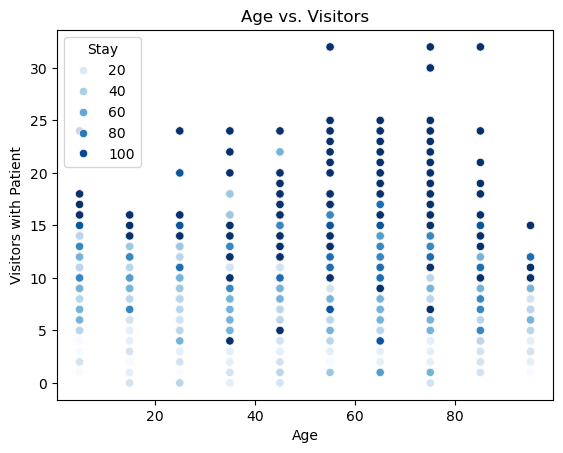

In [23]:
df_plot = preparedDataFrame
sns.scatterplot(x='Age', y='Visitors with Patient', hue='Stay', data=df_plot, palette='Blues')
plt.title('Age vs. Visitors')

<Axes: xlabel='Age', ylabel='Stay'>

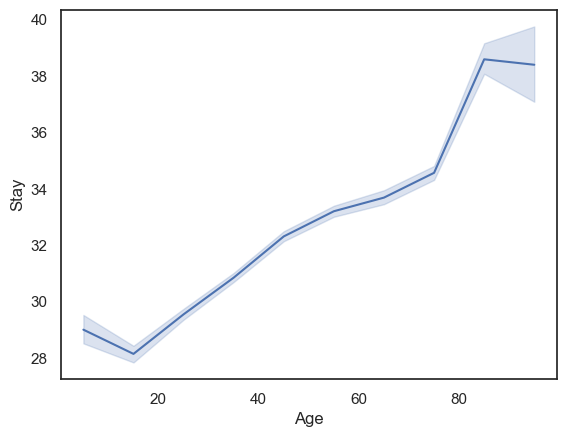

In [24]:
df_plot = df_plot.sort_values(["Age", "Stay"], ascending=False)
sns.set_theme(style="white")
sns.lineplot(x="Age", y="Stay", data=df_plot)

<Axes: xlabel='Visitors with Patient', ylabel='Stay'>

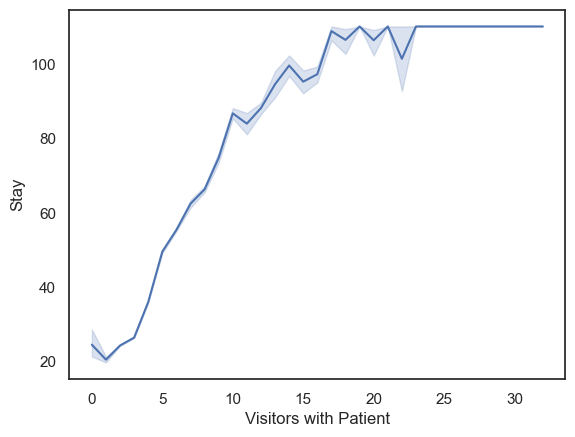

In [25]:
sns.lineplot(x="Visitors with Patient", y="Stay", data=df_plot)

<Axes: xlabel='Age', ylabel='Stay'>

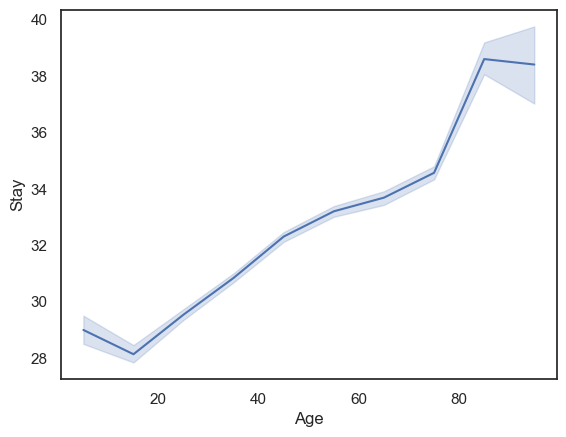

In [26]:
sns.lineplot(x="Age", y="Stay", data=df_plot)

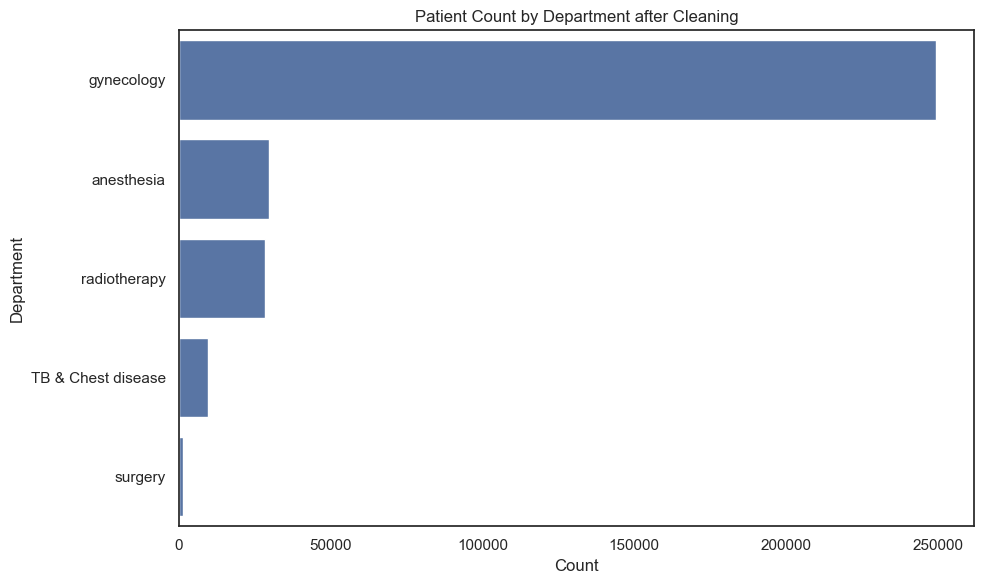

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Department", order=df["Department"].value_counts().index)
plt.title("Patient Count by Department after Cleaning")
plt.xlabel("Count")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

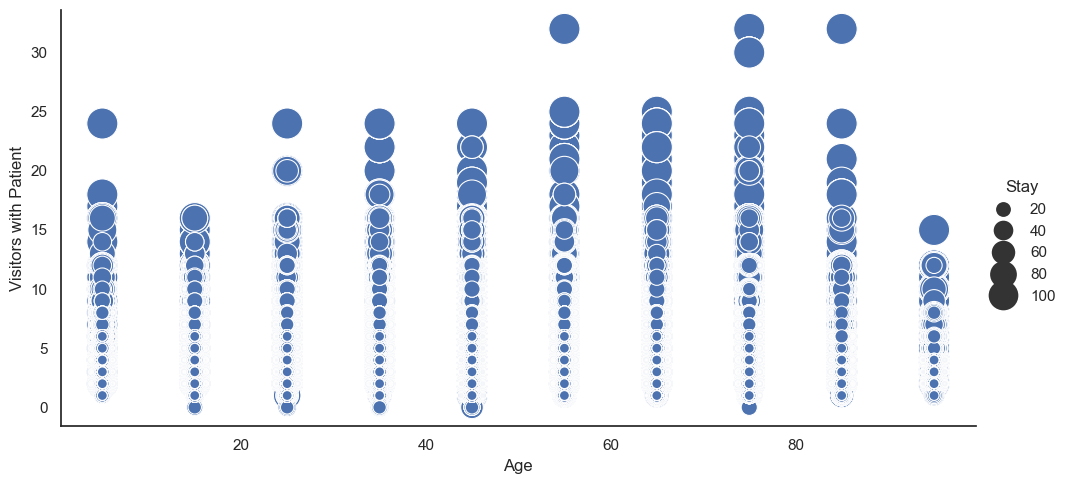

In [28]:
sns.relplot(x="Age", y="Visitors with Patient", size="Stay", data=df_plot, sizes=(50, 500), height=5, aspect=2)

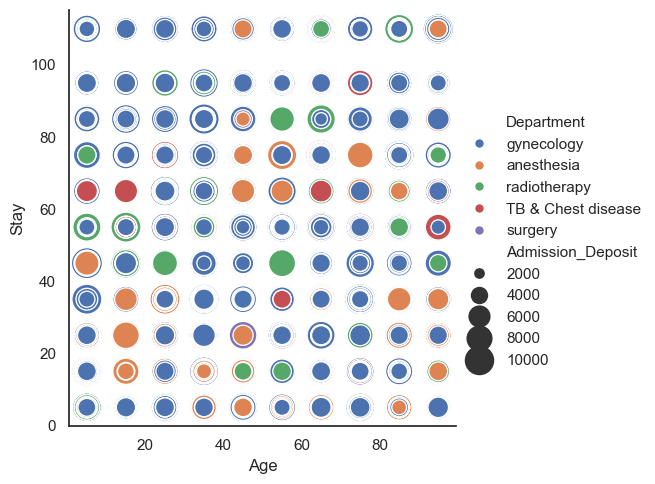

In [29]:
sns.set_theme(style="white")
sns.relplot(x="Age", y="Stay", size="Admission_Deposit", hue="Department", data=df_plot, sizes=(50, 500))